# Project Introduction: Telecom Customer Churn Analysis

### In the telecom industry, customer churn refers to the situation where a customer stops using a company’s services, either by switching to a competitor or discontinuing service entirely. In this project, churn is treated as a binary outcome, where a value of 1 indicates that a customer has left the service and 0 indicates that the customer has remained active.

### Customer churn is a critical business challenge for telecom companies due to the highly competitive nature of the industry. With multiple providers offering similar services, customers can easily switch if they perceive better pricing, service quality, or value elsewhere. As a result, even small increases in churn can lead to significant revenue losses over time.

### Measuring and reducing churn is important because acquiring new customers is far more expensive than retaining existing ones. Retained customers not only provide stable recurring revenue but are also more likely to purchase additional services and remain loyal over longer periods. By understanding which factors contribute to customer churn, telecom companies can design targeted retention strategies such as personalized offers, service improvements, or proactive customer engagement.

### The goal of this project is to analyze customer behavior and service usage patterns to identify key drivers of churn and to build a predictive model that estimates the likelihood of a customer churning. These insights can support data-driven decision-making and help telecom providers prioritize retention efforts toward customers who are most at risk of leaving.

In [2]:
# importing libraries
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modeling
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


# Dataset Overview 

In [4]:
# importing the data
data = pd.read_csv(r"C:\Users\HP\Desktop\Telecom churn(python)\data.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis(EDA)

In [6]:
# checking datatypes 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# checking null values
data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# checking for duplicates
data['customerID'].duplicated().sum()


0

In [9]:
# There are no duplicates but our [TotalCharges] column is an object 
# Change the  [TotalCharges] column to a float
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# checking nulls after updating column type
data.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
# check the columns with null values for total charges
data[data['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


#### From the above, we realize that total charges is null for new customers that is those that have been with the telecom for less than a month

In [13]:
# we are going to replace the null with 0 since they are new
data.loc[data['tenure'] == 0, 'TotalCharges'] = 0
data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
# checking the distribution of churn 
data["Churn"].value_counts()



Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
# checking the distribution of churn among categorical columns
def churn_summary_table(df, col):
    # Raw counts
    counts = pd.crosstab(df[col], df['Churn'])

    # Percentages by row
    percentages = pd.crosstab(
        df[col],
        df['Churn'],
        normalize='index'
    ) * 100

    summary = counts.copy()
    summary.columns = ['No_Churn_Count', 'Churn_Count']
    summary['Churn_Rate_%'] = percentages['Yes'].round(2)
    summary['No_Churn_%'] = percentages['No'].round(2)

    return summary


cols = [
    'SeniorCitizen', 'gender', 'PhoneService', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

for col in cols:
    print(f"\nChurn Summary for {col}")
    display(churn_summary_table(data, col))



Churn Summary for SeniorCitizen


,No_Churn_Count,Churn_Count,Churn_Rate_%,No_Churn_%
SeniorCitizen,,,,
0,4508,1393,23.61,76.39
1,666,476,41.68,58.32



Churn Summary for gender


,No_Churn_Count,Churn_Count,Churn_Rate_%,No_Churn_%
gender,,,,
Female,2549,939,26.92,73.08
Male,2625,930,26.16,73.84



Churn Summary for PhoneService


...

,No_Churn_Count,Churn_Count,Churn_Rate_%,No_Churn_%
StreamingMovies,,,,
No,1847,938,33.68,66.32
No internet service,1413,113,7.40,92.60
Yes,1914,818,29.94,70.06



Churn Summary for Contract


,No_Churn_Count,Churn_Count,Churn_Rate_%,No_Churn_%
Contract,,,,
Month-to-month,2220,1655,42.71,57.29
One year,1307,166,11.27,88.73
Two year,1647,48,2.83,97.17



Churn Summary for PaymentMethod


,No_Churn_Count,Churn_Count,Churn_Rate_%,No_Churn_%
PaymentMethod,,,,
Bank transfer (automatic),1286,258,16.71,83.29
Credit card (automatic),1290,232,15.24,84.76
Electronic check,1294,1071,45.29,54.71
Mailed check,1304,308,19.11,80.89


## Key Exploratory Insights

Based on exploratory data analysis, the following patterns were observed:

1. **Senior citizens exhibit significantly higher churn rates than non-senior citizens**  
   Churn among senior citizens is substantially higher (41.68%) compared to non-senior citizens (23.61%).

2. **Fiber optic internet users have the highest churn rates**  
   Customers using fiber optic internet services show much higher churn (41.89%) compared to customers using DSL or no internet service combined (26.36%).

3. **Lack of online security is strongly associated with churn**  
   Customers without online security churn at more than twice the rate of those with online security (41.77% vs 22.01%).

4. **Customers without online backup churn significantly more**  
   Churn among customers without online backup is nearly double that of customers with online backup (39.93% vs 21.53%).

5. **Absence of technical support greatly increases churn risk**  
   Customers without tech support churn at almost three times the rate of those with tech support (41.64% vs 15.17%).

6. **Streaming services have minimal impact on churn**  
   Churn rates for customers with and without streaming TV or streaming movies are relatively similar (33.07% vs 30.07%), suggesting limited influence on churn behavior.

7. **Contract type is one of the strongest churn drivers**  
   Month-to-month customers churn at a much higher rate (42.71%) compared to customers on one-year or two-year contracts combined (14.10%).


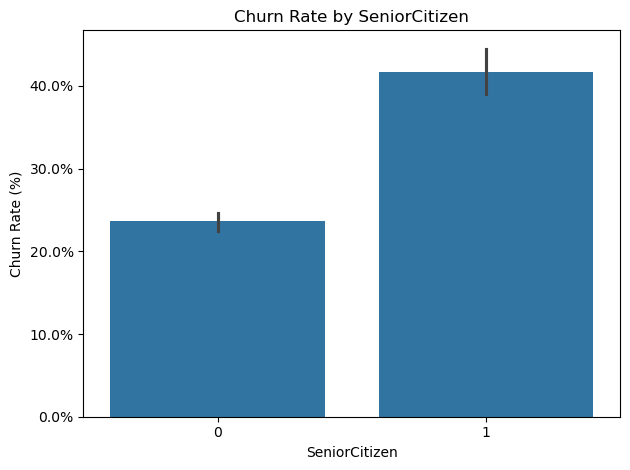

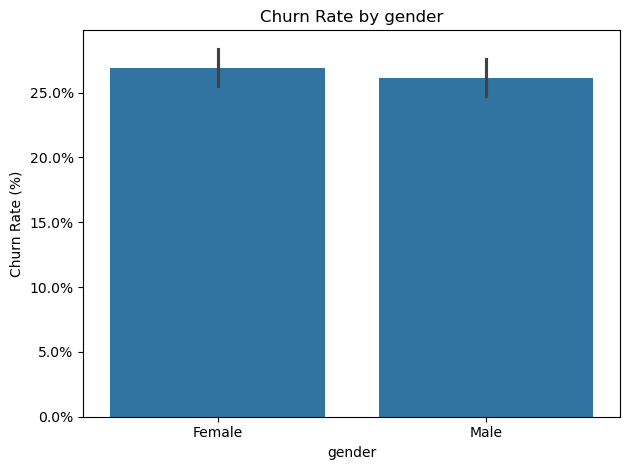

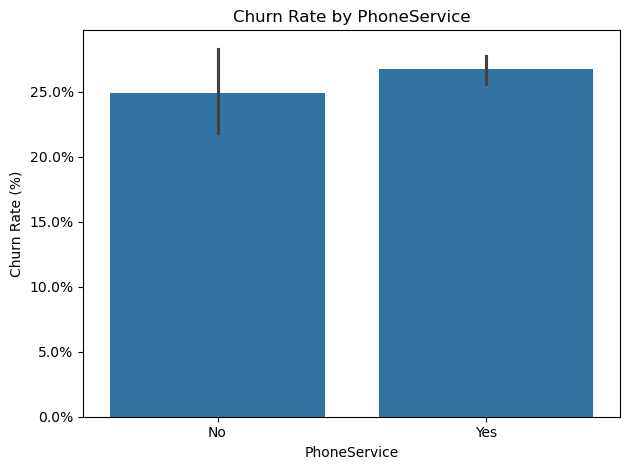

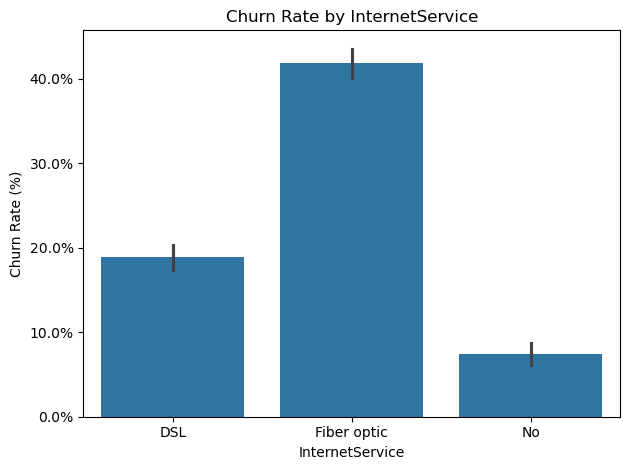

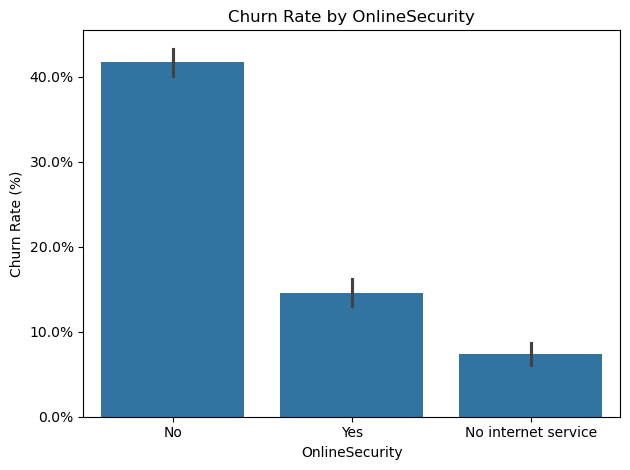

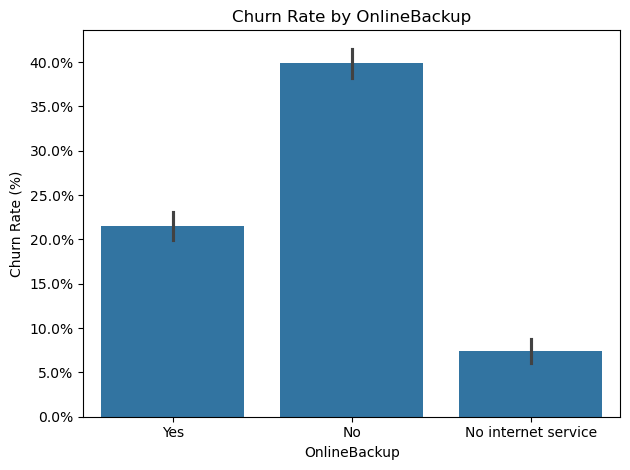

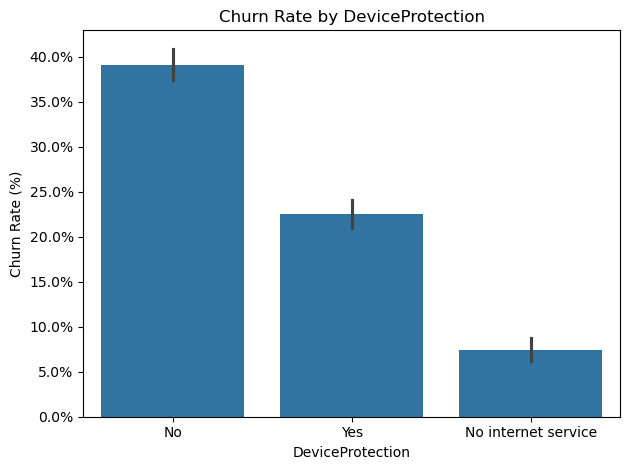

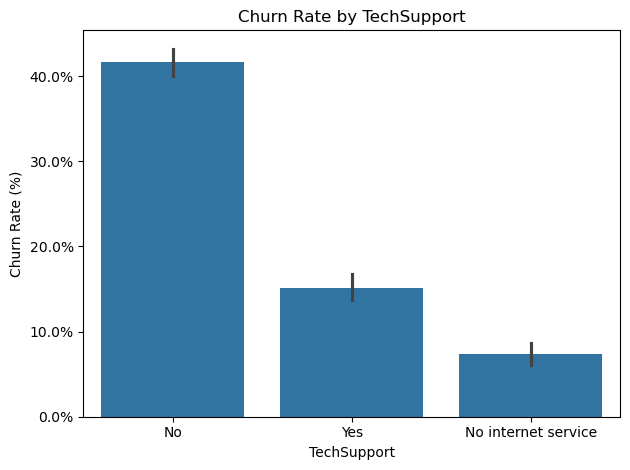

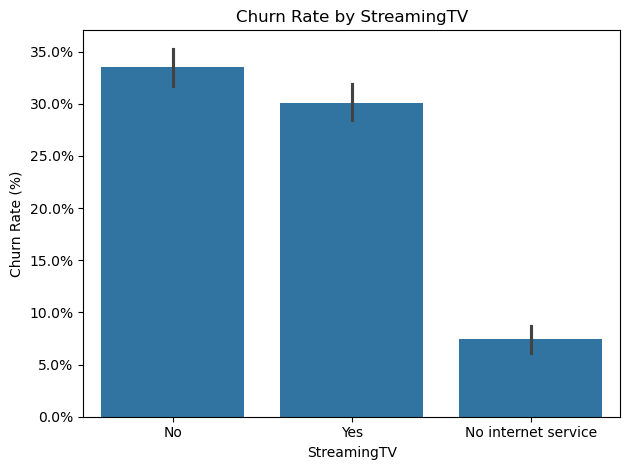

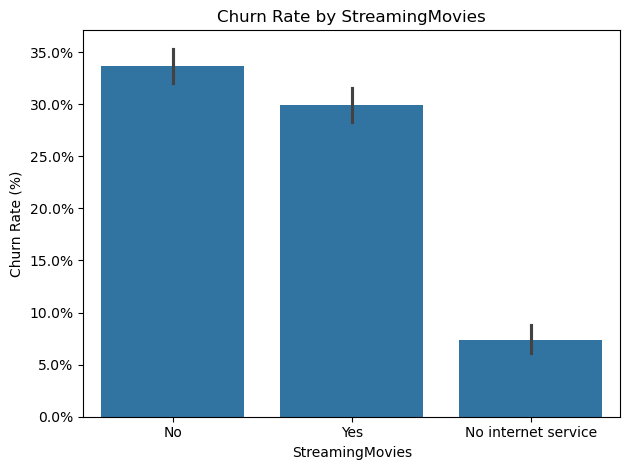

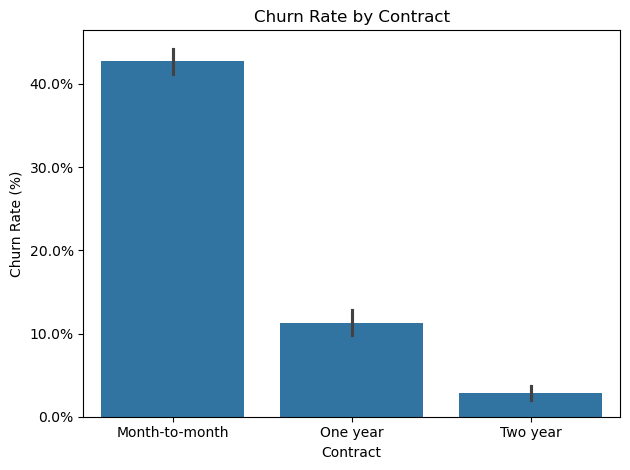

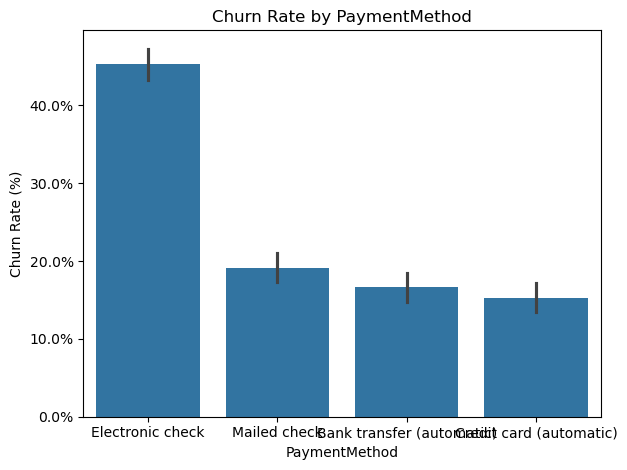

In [17]:
## plotting churn for various categories
data['Churn_num'] = data['Churn'].map({'Yes': 1, 'No': 0})


for col in cols:
    ax = sns.barplot(
        x=col,
        y='Churn_num',
        data=data,
        estimator='mean'
    )

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Churn Rate (%)')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()




In [18]:
data.drop(columns='Churn_num', inplace=True)


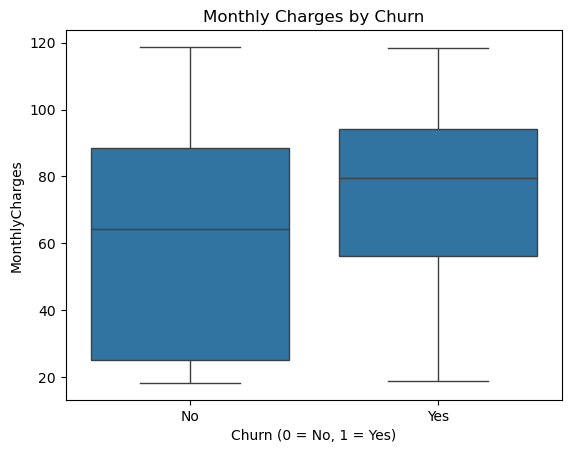

In [19]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.show()


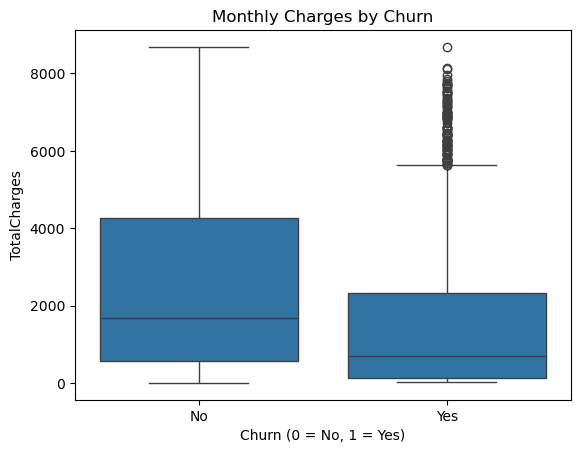

In [20]:
sns.boxplot(x='Churn', y='TotalCharges', data=data)
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.show()

In [21]:
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = ['0–12', '13–24', '25–48', '49–72']

data['tenure_bin'] = pd.cut(
    data['tenure'],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)


In [22]:
data['tenure_bin'].value_counts()


tenure_bin
49–72    2239
0–12     2186
25–48    1594
13–24    1024
Name: count, dtype: int64

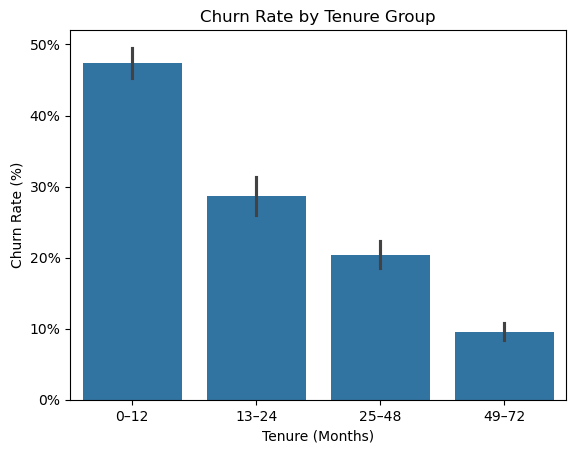

In [23]:
data['Churn_num'] = data['Churn'].map({'Yes': 1, 'No': 0})

ax = sns.barplot(
    x='tenure_bin',
    y='Churn_num',
    data=data,
    estimator='mean'
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure (Months)')
plt.show()


### From the above, we notice that new customers(1year or less) are churning more than those who have been with the telecom company longer


In [25]:
data.drop(columns='Churn_num', inplace=True)


# Feature Engineering & Data Preparation for Modeling

In [27]:
# we are going to change the yes and no in churn to 0's and 1's 
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bin
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0–12
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25–48
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0–12
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25–48
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0–12


In [28]:
# encode binary categorical features
binary_map = {
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0
}

binary_features = [
     'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'PaperlessBilling'
]

for col in binary_features:
    data[col] = data[col].map(binary_map)


In [29]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bin
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0,0–12
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,0,0,0,One year,0,Mailed check,56.95,1889.50,0,25–48
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,0–12
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,25–48
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,0–12


In [30]:
# drop columns that wont be used in the modelling
data = data.drop(columns=[
    'customerID',     # identifier
    'tenure_bin'      # EDA-only feature
])


# Modeling

In [32]:
X = data.drop(columns='Churn')
y = data['Churn']


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [34]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])


In [35]:
model.fit(X_train, y_train)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'InternetService',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

# Model Evaluation

In [37]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[749 286]
 [ 80 294]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


ROC-AUC: 0.8418739827946989


In [38]:


# get fitted logistic regression inside the pipeline
clf = model.named_steps['classifier']
pre = model.named_steps['preprocessor']

# get feature names after preprocessing
num_names = pre.transformers_[0][2]
cat_encoder = pre.transformers_[1][1]
cat_names = cat_encoder.get_feature_names_out(pre.transformers_[1][2])

# remainder (binary columns) names
all_cols = X.columns.to_list()
used_cols = list(num_names) + list(pre.transformers_[1][2])
remainder_names = [c for c in all_cols if c not in used_cols]

feature_names = list(num_names) + list(cat_names) + remainder_names

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': clf.coef_[0],
})
coef_df['odds_ratio'] = np.exp(coef_df['coef'])
coef_df = coef_df.sort_values('odds_ratio', ascending=False)

coef_df.head(15)


,feature,coef,odds_ratio
4,InternetService_Fiber optic,1.078480,2.940207
2,TotalCharges,0.485826,1.625517
9,PaymentMethod_Electronic check,0.405849,1.500575
21,StreamingMovies,0.363801,1.438788
20,StreamingTV,0.338624,1.403015
22,PaperlessBilling,0.338541,1.402899
15,MultipleLines,0.295516,1.343820
11,SeniorCitizen,0.153185,1.165541
10,PaymentMethod_Mailed check,0.053353,1.054801
3,gender_Male,0.032086,1.032607


### The model shows that service type, billing method, and pricing-related features are the strongest drivers of churn, while household stability and value-added services reduce churn risk.

# Business Recommendations

- **Target fiber optic customers for retention**  
  Fiber optic subscribers exhibit the highest churn risk and should be prioritized for proactive retention campaigns.

- **Incentivize auto-pay over electronic checks**  
  Customers using electronic check payments show significantly higher churn rates; encouraging automatic payment methods can reduce friction and improve retention.

- **Bundle value-added services like OnlineBackup**  
  Customers with value-added services are less likely to churn, suggesting that bundling these services can increase customer stickiness.

- **Focus retention efforts on high-charge, streaming-heavy customers**  
  Customers with higher total charges and multiple streaming services demonstrate elevated churn risk and may benefit from targeted pricing or loyalty offers.

- **Prioritize new and non-family customers**  
  Customers with shorter tenure and without dependents are more likely to churn, highlighting the importance of early-stage engagement and onboarding strategies.



## Conclusion

### `This project demonstrated an end-to-end churn analysis for a telecom provider, covering exploratory data analysis, feature engineering, predictive modeling, and business recommendations. The logistic regression model identified key churn drivers related to service type, billing behavior, and customer tenure. These insights can support data-driven retention strategies aimed at reducing churn and improving customer lifetime value.
